# Predictive Modelling of District-Level O-Level Pass Rates in Zimbabwe

**Author:** Cesario Machinga
**Programme:** Level 4 Honors Degree in Data Science and Informatics
**Submission:** April 2026

---

## About this notebook

This notebook implements the full predictive pipeline for the project, mapped explicitly to the **five project objectives** stated in Chapter 1 of the dissertation:

1. **Collect and pre-process** district-level educational and socio-economic data relevant to O-Level performance.
2. **Explore and analyse** factors influencing O-Level pass rates across districts.
3. **Develop predictive models** using appropriate data science and machine-learning techniques.
4. **Evaluate the performance** and accuracy of the developed models.
5. **Provide actionable insights** to support education policy and planning.

### Methodological note — what's different from the original pipeline

The original analysis reported R² = 0.975 from a model that included `Previous_Year_Pass_Rate_Pct` as a feature, evaluated with random K-fold cross-validation. Two issues motivated the redesign:

- The autoregressive feature (`Previous_Year_Pass_Rate_Pct`) carries a 0.96 correlation with the target on its own, dominating learning and making "predictive" performance partly a function of persistence rather than the socio-educational factors of interest.
- Random K-fold splits a panel where 78.8% of variance lies *between districts*. Without grouping, the same district appears in train and test folds, so the model is partly memorising district baselines.

This notebook addresses both by training **two model families** with **two evaluation regimes**:

| Family | Features | Answers the question |
|---|---|---|
| **Forecast model** | All features incl. `Previous_Year_Pass_Rate_Pct` | What will this district score next year? |
| **Driver model** | Excludes autoregressive features | What underlying factors drive pass rates? |

Both are evaluated with (a) a **temporal hold-out** (train ≤ 2021, test 2022–2024) and (b) **GroupKFold cross-validation by district** so the test fold contains districts unseen in training.

---
## 0. Environment Setup

Imports, random seed, plot style, and output directory creation.


In [1]:
# Core scientific stack
import os, json, warnings, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import shap

# Reproducibility
warnings.filterwarnings("ignore")
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")

# Project paths — match the FastAPI webapp's expected layout
BASE_DIR     = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR     = BASE_DIR / "data"
OUTPUT_DIR   = BASE_DIR / "output"
MODELS_DIR   = OUTPUT_DIR / "models"
TABLES_DIR   = OUTPUT_DIR / "tables"
FIGURES_DIR  = OUTPUT_DIR / "figures"

for d in [DATA_DIR, MODELS_DIR, TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Workspace ready.")
print(f"  Base   : {BASE_DIR}")
print(f"  Models : {MODELS_DIR}")
print(f"  Tables : {TABLES_DIR}")
print(f"  Figures: {FIGURES_DIR}")

C:\Users\Cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Workspace ready.
  Base   : c:\Users\Cesar\Documents\Final Project\zimsec_project\zimsec_project
  Models : c:\Users\Cesar\Documents\Final Project\zimsec_project\zimsec_project\output\models
  Tables : c:\Users\Cesar\Documents\Final Project\zimsec_project\zimsec_project\output\tables
  Figures: c:\Users\Cesar\Documents\Final Project\zimsec_project\zimsec_project\output\figures


---
## 1. Objective 1 — Data Collection & Preprocessing

### 1.1 Load the dataset

The dataset compiles ten years of ZIMSEC O-Level results (2015–2024) for 71 districts across all ten Zimbabwean provinces, joined with socio-economic indicators from ZIMSTAT and infrastructure indices from MoPSE administrative records. Each row is one district-year-sitting (June or November).


In [2]:
df = pd.read_csv(DATA_DIR / "zimsec_olevel_district_data.csv")

print(f"Rows           : {len(df):,}")
print(f"Columns        : {df.shape[1]}")
print(f"Districts      : {df['District'].nunique()}")
print(f"Provinces      : {df['Province'].nunique()}")
print(f"Year range     : {df['Year'].min()}–{df['Year'].max()}")
print(f"Sittings       : {sorted(df['Setting'].unique())}")
print(f"Total cells    : {df.size:,}")
df.head(3)

Rows           : 1,420
Columns        : 21
Districts      : 71
Provinces      : 10
Year range     : 2015–2024
Sittings       : ['June', 'November']
Total cells    : 29,820


,District,Province,Year,Setting,Pass_Rate_Pct,Number_of_Students,Number_of_Schools,Pupil_Teacher_Ratio,Textbook_Availability_Index,ICT_Resource_Index,...,Proportion_Schools_With_Science_Labs,Poverty_Incidence_Pct,Adult_Literacy_Rate_Pct,Unemployment_Rate_Pct,Avg_Household_Income_USD,Youth_Population_Density,Rural_Urban,Distance_to_Exam_Center_km,Previous_Year_Pass_Rate_Pct,Grade7_Pass_Rate_Pct
0,Bulawayo,Bulawayo,2015,June,77.0,27865,99,30.0,0.74,0.76,...,0.85,36.5,90.6,22.4,533.0,402.7,Urban,2.7,79.6,74.6
1,Bulawayo,Bulawayo,2015,November,87.0,51792,100,30.0,0.73,0.68,...,0.83,36.1,91.9,24.1,565.0,410.0,Urban,2.6,77.0,79.7
2,Bulawayo,Bulawayo,2016,June,75.6,27363,100,28.9,0.76,0.75,...,0.81,37.4,90.7,20.3,523.0,417.2,Urban,2.5,87.0,79.8


### 1.2 Data Quality Audit

Before any modelling we verify completeness, check for duplicates, and inspect each column's domain.


In [3]:
# Missing values
missing = df.isna().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "  (none — dataset is complete)")
print(f"\nDuplicate rows : {df.duplicated().sum()}")
print(f"\nDtype summary  :")
print(df.dtypes.value_counts())

# Numeric range sanity-check
print("\nKey-variable ranges:")
for col in ['Pass_Rate_Pct', 'Pupil_Teacher_Ratio', 'Poverty_Incidence_Pct']:
    print(f"  {col:30s} min={df[col].min():.2f}  max={df[col].max():.2f}  mean={df[col].mean():.2f}")

Columns with missing values:
  (none — dataset is complete)

Duplicate rows : 0

Dtype summary  :
float64    14
object      4
int64       3
Name: count, dtype: int64

Key-variable ranges:
  Pass_Rate_Pct                  min=8.00  max=95.10  mean=41.32
  Pupil_Teacher_Ratio            min=18.00  max=61.40  mean=41.98
  Poverty_Incidence_Pct          min=11.70  max=91.00  mean=57.54


### 1.3 Feature Engineering

Two binary indicators derived from categorical columns:

- `Setting_Nov` — 1 for November sittings (the larger of the two), 0 for June
- `Is_Urban`   — 1 for urban districts, 0 for rural

These keep the categorical information available to tree-based models without forcing one-hot expansion. The full categorical names (`District`, `Province`, `Setting`, `Rural_Urban`) are retained for reporting and grouping but excluded from the feature matrix.


In [4]:
df['Setting_Nov'] = (df['Setting']     == 'November').astype(int)
df['Is_Urban']    = (df['Rural_Urban'] == 'Urban').astype(int)

# Persist the cleaned frame for the FastAPI webapp
df.to_csv(DATA_DIR / "cleaned_data.csv", index=False)
print(f"Saved cleaned dataset: {DATA_DIR/'cleaned_data.csv'}")
print(f"New columns: Setting_Nov, Is_Urban")
df[['Setting','Setting_Nov','Rural_Urban','Is_Urban']].head()

Saved cleaned dataset: c:\Users\Cesar\Documents\Final Project\zimsec_project\zimsec_project\data\cleaned_data.csv
New columns: Setting_Nov, Is_Urban


,Setting,Setting_Nov,Rural_Urban,Is_Urban
0,June,0,Urban,1
1,November,1,Urban,1
2,June,0,Urban,1
3,November,1,Urban,1
4,June,0,Urban,1


---
## 2. Objective 2 — Exploratory Data Analysis

### 2.1 Descriptive statistics


In [5]:
numeric_summary = df.select_dtypes(include=[np.number]).describe().T
numeric_summary[['mean','std','min','25%','50%','75%','max']].round(2)

,mean,std,min,25%,50%,75%,max
Year,2019.50,2.87,2015.00,2017.00,2019.50,2022.00,2024.00
Pass_Rate_Pct,41.32,18.71,8.00,26.40,38.25,52.62,95.10
Number_of_Students,7906.43,11177.30,554.00,2369.75,3737.50,6627.25,65675.00
Number_of_Schools,29.03,23.98,4.00,15.00,25.00,30.00,126.00
Pupil_Teacher_Ratio,41.98,10.94,18.00,32.18,44.20,50.90,61.40
Textbook_Availability_Index,0.43,0.20,0.11,0.27,0.39,0.57,0.98
ICT_Resource_Index,0.36,0.21,0.02,0.22,0.31,0.46,0.95
School_Infrastructure_Index,0.44,0.22,0.12,0.26,0.40,0.55,0.98
Proportion_Schools_With_Science_Labs,0.33,0.22,0.05,0.16,0.26,0.44,0.93
Poverty_Incidence_Pct,57.54,17.71,11.70,43.88,60.60,70.80,91.00


### 2.2 Temporal trend — national pass rate, 2015–2024

The national mean and the ±1 SD band reveal both the overall trajectory and the dispersion across districts each year.


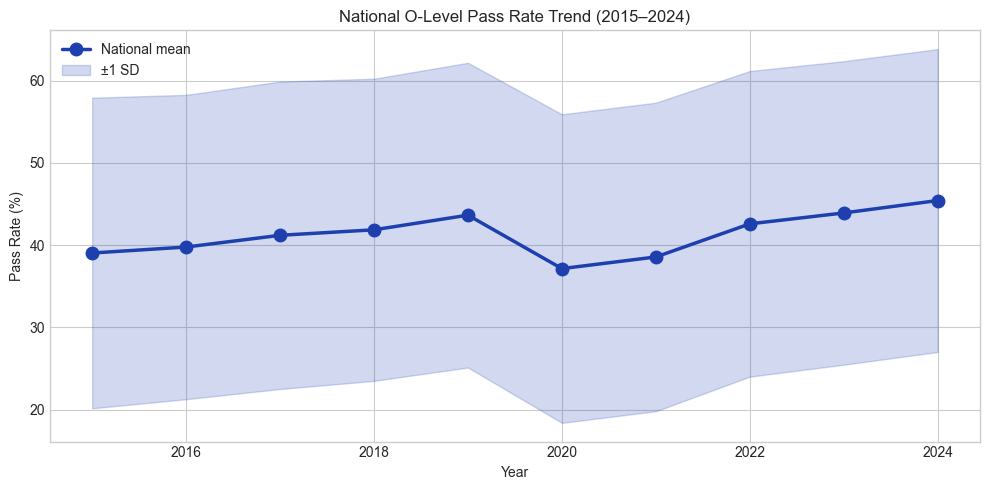

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
yearly = df.groupby('Year')['Pass_Rate_Pct'].agg(['mean', 'std'])
ax.plot(yearly.index, yearly['mean'], 'o-', color='#1e40af', lw=2.5, ms=9, label='National mean')
ax.fill_between(yearly.index,
                yearly['mean'] - yearly['std'],
                yearly['mean'] + yearly['std'],
                alpha=0.2, color='#1e40af', label='±1 SD')
ax.set(title='National O-Level Pass Rate Trend (2015–2024)',
       xlabel='Year', ylabel='Pass Rate (%)')
ax.legend(); plt.tight_layout()
fig.savefig(FIGURES_DIR/'pass_rate_trends.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.3 Urban vs Rural performance gap


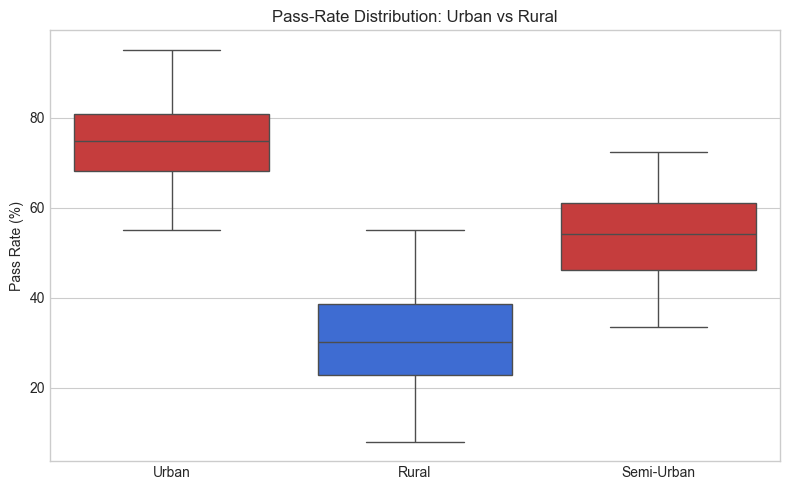

Urban-rural mean gap: 43.7 percentage points


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Rural_Urban', y='Pass_Rate_Pct', ax=ax,
            palette=['#dc2626', '#2563eb'])
ax.set(title='Pass-Rate Distribution: Urban vs Rural',
       ylabel='Pass Rate (%)', xlabel='')
plt.tight_layout()
fig.savefig(FIGURES_DIR/'urban_rural_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

gap = (df[df['Rural_Urban']=='Urban']['Pass_Rate_Pct'].mean()
       - df[df['Rural_Urban']=='Rural']['Pass_Rate_Pct'].mean())
print(f"Urban-rural mean gap: {gap:.1f} percentage points")

### 2.4 Province-level performance


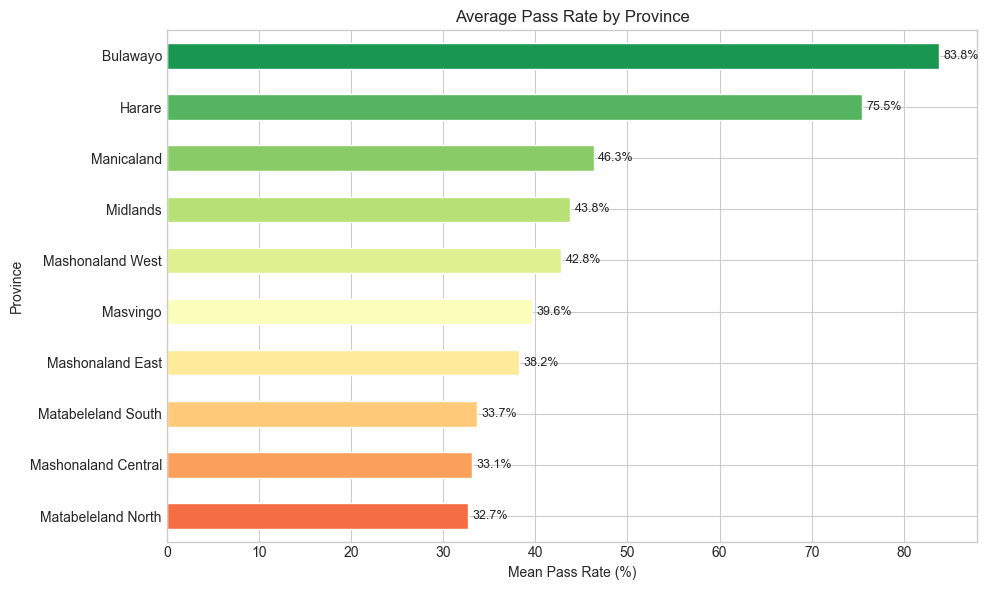

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
prov = df.groupby('Province')['Pass_Rate_Pct'].mean().sort_values()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(prov)))
prov.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set(title='Average Pass Rate by Province', xlabel='Mean Pass Rate (%)')
for i, v in enumerate(prov.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR/'province_chart.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.5 Correlation matrix

Pearson correlations among numeric features. The strong cluster of intercorrelations among socio-economic indicators is itself a finding — many "predictors" are proxies for the same underlying construct (district affluence).


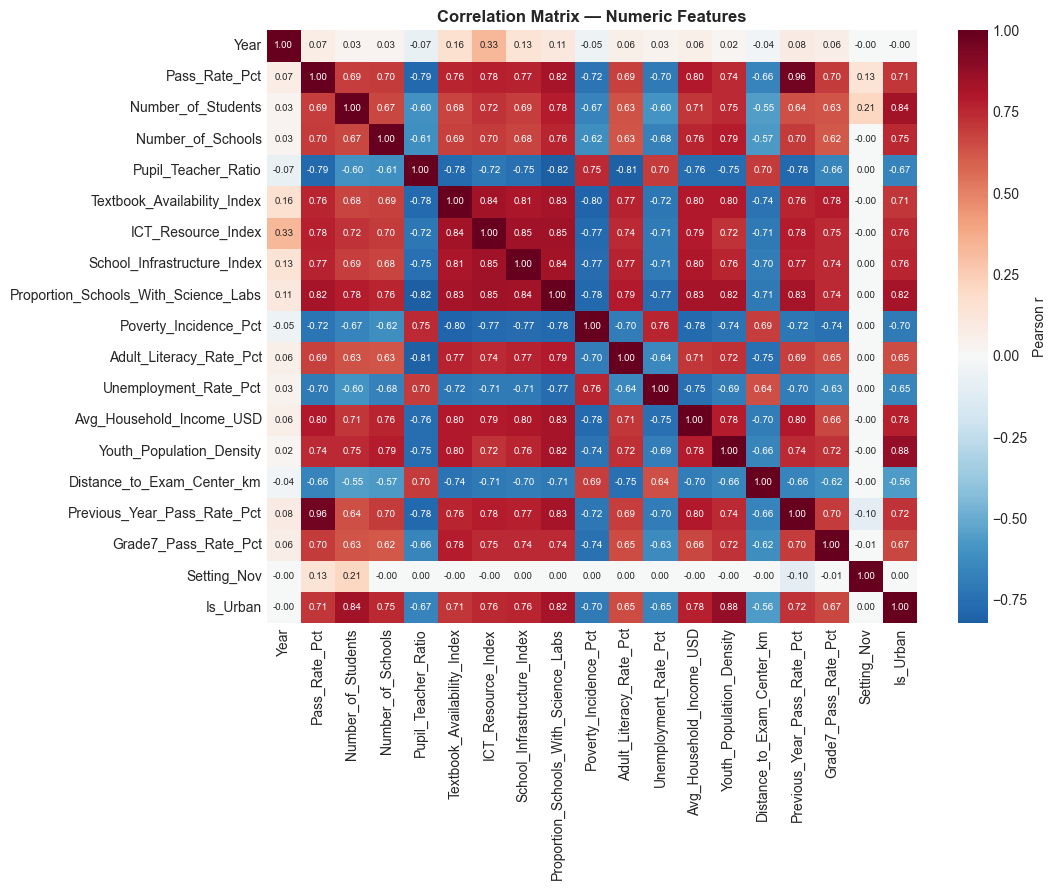

Top correlates of Pass_Rate_Pct:
Pass_Rate_Pct                           1.000
Previous_Year_Pass_Rate_Pct             0.958
Proportion_Schools_With_Science_Labs    0.823
Avg_Household_Income_USD                0.801
Pupil_Teacher_Ratio                     0.786
ICT_Resource_Index                      0.777
School_Infrastructure_Index             0.772
Textbook_Availability_Index             0.760
Name: Pass_Rate_Pct, dtype: float64


In [9]:
numeric_df = df.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, annot_kws={'size': 7}, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR/'correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top correlates of Pass_Rate_Pct:")
print(numeric_df.corr()['Pass_Rate_Pct'].abs().sort_values(ascending=False).head(8).round(3))

---
## 3. Cross-Validation Strategy — Why Default K-Fold Fails Here

Before training, we diagnose the variance structure of the target. This determines what an honest cross-validation scheme looks like.


In [10]:
overall_std        = df['Pass_Rate_Pct'].std()
within_district_sd = df.groupby('District')['Pass_Rate_Pct'].std().mean()
between_pct        = (1 - within_district_sd / overall_std) * 100

print(f"Overall SD of pass rate          : {overall_std:.2f} pp")
print(f"Average within-district SD       : {within_district_sd:.2f} pp")
print(f"=> Between-district variance     : {between_pct:.1f}% of total")
print(f"=> Within-district variance      : {100-between_pct:.1f}% of total")

# What does Previous_Year alone explain?
from sklearn.linear_model import LinearRegression
X1 = df[['Previous_Year_Pass_Rate_Pct']].values
y  = df['Pass_Rate_Pct'].values
m1 = LinearRegression().fit(X1, y)
print(f"\nR² from Previous_Year alone     : {m1.score(X1, y):.4f}")

Overall SD of pass rate          : 18.71 pp
Average within-district SD       : 3.97 pp
=> Between-district variance     : 78.8% of total
=> Within-district variance      : 21.2% of total

R² from Previous_Year alone     : 0.9187


**Implications of this diagnostic.**

- 78.8% of variance is *between* districts — meaning a model that simply remembered each district's mean pass rate would explain ~79% of the variance with zero learning. Random K-fold lets the model see Bulawayo in fold 1's training and predict Bulawayo in fold 1's test, inflating apparent performance.
- `Previous_Year_Pass_Rate_Pct` alone gives R² ≈ 0.92. Any model that includes it inherits this baseline, regardless of the contribution of socio-economic features.

**Strategy adopted in this notebook:**

1. **Temporal hold-out**: train on 2015–2021 (994 rows), test on 2022–2024 (426 rows). Mirrors how the model would be deployed.
2. **GroupKFold by district** for cross-validation on the training set. The held-out fold contains districts the model has never seen, so CV measures *generalisation*, not memorisation.
3. **Two model families** to disentangle persistence from drivers:
   - *Forecast model*: includes `Previous_Year_Pass_Rate_Pct` — answers "what will this district score?"
   - *Driver model*: excludes autoregressive features — answers "what factors actually drive performance?"


---
## 4. Objective 3 — Model Development

### 4.1 Train/test split and feature sets


In [11]:
train_df = df[df['Year'] <= 2021].copy()
test_df  = df[df['Year'] >= 2022].copy()

DROP_COLS = ['District', 'Province', 'Setting', 'Rural_Urban', 'Pass_Rate_Pct']
FEATURES_FORECAST = [c for c in df.columns if c not in DROP_COLS]
FEATURES_DRIVER   = [c for c in FEATURES_FORECAST if c != 'Previous_Year_Pass_Rate_Pct']

print(f"Train set: {len(train_df):,} rows ({train_df['Year'].min()}–{train_df['Year'].max()})")
print(f"Test  set: {len(test_df):,} rows ({test_df['Year'].min()}–{test_df['Year'].max()})")
print(f"\nForecast features ({len(FEATURES_FORECAST)}):\n  {FEATURES_FORECAST}")
print(f"\nDriver features   ({len(FEATURES_DRIVER)}):\n  {FEATURES_DRIVER}")

Train set: 994 rows (2015–2021)
Test  set: 426 rows (2022–2024)

Forecast features (18):
  ['Year', 'Number_of_Students', 'Number_of_Schools', 'Pupil_Teacher_Ratio', 'Textbook_Availability_Index', 'ICT_Resource_Index', 'School_Infrastructure_Index', 'Proportion_Schools_With_Science_Labs', 'Poverty_Incidence_Pct', 'Adult_Literacy_Rate_Pct', 'Unemployment_Rate_Pct', 'Avg_Household_Income_USD', 'Youth_Population_Density', 'Distance_to_Exam_Center_km', 'Previous_Year_Pass_Rate_Pct', 'Grade7_Pass_Rate_Pct', 'Setting_Nov', 'Is_Urban']

Driver features   (17):
  ['Year', 'Number_of_Students', 'Number_of_Schools', 'Pupil_Teacher_Ratio', 'Textbook_Availability_Index', 'ICT_Resource_Index', 'School_Infrastructure_Index', 'Proportion_Schools_With_Science_Labs', 'Poverty_Incidence_Pct', 'Adult_Literacy_Rate_Pct', 'Unemployment_Rate_Pct', 'Avg_Household_Income_USD', 'Youth_Population_Density', 'Distance_to_Exam_Center_km', 'Grade7_Pass_Rate_Pct', 'Setting_Nov', 'Is_Urban']


### 4.2 Training routine

A single function trains all five algorithms — Linear, Ridge, Lasso, Random Forest, XGBoost — with `GridSearchCV` for hyperparameter tuning, then evaluates each on the temporal hold-out and via 5-fold `GroupKFold` (grouped by district).


In [12]:
def adjusted_r2(r2: float, n: int, p: int) -> float:
    """Adjusted R² penalising the number of predictors."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def train_model_family(features, family_name):
    """Train all five algorithms on `features`. Return (results_df, fitted_models, scaler)."""
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[features])
    X_test  = scaler.transform(test_df[features])
    y_train = train_df['Pass_Rate_Pct'].values
    y_test  = test_df['Pass_Rate_Pct'].values

    grids = {
        'Linear Regression': (LinearRegression(), {}),
        'Ridge Regression' : (Ridge(random_state=42), {'alpha': [0.1, 1, 10]}),
        'Lasso Regression' : (Lasso(random_state=42, max_iter=10000), {'alpha': [0.01, 0.1, 1]}),
        'Random Forest'    : (RandomForestRegressor(random_state=42, n_jobs=-1),
                              {'n_estimators': [200], 'max_depth': [6, 10, None]}),
        'XGBoost'          : (XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
                              {'n_estimators': [300], 'max_depth': [3, 5],
                               'learning_rate': [0.05, 0.1]}),
    }

    gkf = GroupKFold(n_splits=5)
    rows, fitted = [], {}
    for name, (estimator, grid) in grids.items():
        if grid:
            search = GridSearchCV(estimator, grid, cv=5, scoring='r2', n_jobs=-1)
            search.fit(X_train, y_train)
            model = search.best_estimator_
        else:
            model = estimator.fit(X_train, y_train)

        pred = model.predict(X_test)
        r2   = r2_score(y_test, pred)
        rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
        mae  = mean_absolute_error(y_test, pred)
        ar2  = adjusted_r2(r2, len(y_test), len(features))

        cv = cross_val_score(model, X_train, y_train, cv=gkf,
                              groups=train_df['District'], scoring='r2', n_jobs=-1)

        rows.append({
            'Model': name, 'R2': r2, 'Adjusted_R2': ar2,
            'RMSE': rmse, 'MAE': mae,
            'CV_R2_Mean': cv.mean(), 'CV_R2_Std': cv.std(),
        })
        fitted[name] = model
        print(f"[{family_name}] {name:18s}  R²={r2:.4f}  MAE={mae:.2f}  "
              f"GroupKFold CV={cv.mean():.4f}±{cv.std():.4f}")

    results = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
    return results, fitted, scaler

### 4.3 Train Family A — Forecasting Model

Includes `Previous_Year_Pass_Rate_Pct`. Use case: predict next-year pass rates for districts whose recent history is known.


In [13]:
print("Training FORECASTING family (with Previous_Year_Pass_Rate)...\n")
results_forecast, models_forecast, scaler_forecast = train_model_family(
    FEATURES_FORECAST, 'Forecast')

print("\n--- Forecast results (sorted by hold-out R²) ---")
results_forecast.round(4)

Training FORECASTING family (with Previous_Year_Pass_Rate)...

[Forecast] Linear Regression   R²=0.9604  MAE=2.97  GroupKFold CV=0.9708±0.0067
[Forecast] Ridge Regression    R²=0.9604  MAE=2.96  GroupKFold CV=0.9708±0.0067
[Forecast] Lasso Regression    R²=0.9638  MAE=2.80  GroupKFold CV=0.9713±0.0069
[Forecast] Random Forest       R²=0.9719  MAE=2.44  GroupKFold CV=0.9519±0.0208
[Forecast] XGBoost             R²=0.9754  MAE=2.25  GroupKFold CV=0.9615±0.0175

--- Forecast results (sorted by hold-out R²) ---


,Model,R2,Adjusted_R2,RMSE,MAE,CV_R2_Mean,CV_R2_Std
0,XGBoost,0.9754,0.9743,2.8953,2.2550,0.9615,0.0175
1,Random Forest,0.9719,0.9706,3.0949,2.4391,0.9519,0.0208
2,Lasso Regression,0.9638,0.9622,3.5121,2.7999,0.9713,0.0069
3,Ridge Regression,0.9604,0.9586,3.6733,2.9640,0.9708,0.0067
4,Linear Regression,0.9604,0.9586,3.6741,2.9651,0.9708,0.0067


### 4.4 Train Family B — Driver Model

Excludes autoregressive features. Use case: identify which underlying factors drive pass-rate variation across districts. The CV scores here are the honest measure of generalisation — they tell you how well the model would predict for a brand-new district with no historical record.


In [14]:
print("Training DRIVER family (no Previous_Year_Pass_Rate)...\n")
results_driver, models_driver, scaler_driver = train_model_family(
    FEATURES_DRIVER, 'Driver')

print("\n--- Driver results (sorted by hold-out R²) ---")
results_driver.round(4)

Training DRIVER family (no Previous_Year_Pass_Rate)...

[Driver] Linear Regression   R²=0.7791  MAE=7.20  GroupKFold CV=0.6429±0.0969
[Driver] Ridge Regression    R²=0.7794  MAE=7.20  GroupKFold CV=0.6505±0.0927
[Driver] Lasso Regression    R²=0.7676  MAE=7.40  GroupKFold CV=0.6804±0.0751
[Driver] Random Forest       R²=0.9194  MAE=4.04  GroupKFold CV=0.6645±0.1113
[Driver] XGBoost             R²=0.9126  MAE=4.31  GroupKFold CV=0.6515±0.0744

--- Driver results (sorted by hold-out R²) ---


,Model,R2,Adjusted_R2,RMSE,MAE,CV_R2_Mean,CV_R2_Std
0,Random Forest,0.9194,0.9161,5.2389,4.0438,0.6645,0.1113
1,XGBoost,0.9126,0.9089,5.4574,4.3115,0.6515,0.0744
2,Ridge Regression,0.7794,0.7702,8.6700,7.1998,0.6505,0.0927
3,Linear Regression,0.7791,0.7699,8.6743,7.1952,0.6429,0.0969
4,Lasso Regression,0.7676,0.7579,8.8983,7.4032,0.6804,0.0751


---
## 5. Objective 4 — Model Evaluation

### 5.1 Side-by-side comparison


In [15]:
comparison = results_forecast.merge(
    results_driver, on='Model', suffixes=('_Forecast', '_Driver'))
print("Hold-out test (2022-2024) — both families")
comparison[['Model', 'R2_Forecast', 'R2_Driver',
            'MAE_Forecast', 'MAE_Driver',
            'CV_R2_Mean_Forecast', 'CV_R2_Mean_Driver']].round(4)

Hold-out test (2022-2024) — both families


,Model,R2_Forecast,R2_Driver,MAE_Forecast,MAE_Driver,CV_R2_Mean_Forecast,CV_R2_Mean_Driver
0,XGBoost,0.9754,0.9126,2.2550,4.3115,0.9615,0.6515
1,Random Forest,0.9719,0.9194,2.4391,4.0438,0.9519,0.6645
2,Lasso Regression,0.9638,0.7676,2.7999,7.4032,0.9713,0.6804
3,Ridge Regression,0.9604,0.7794,2.9640,7.1998,0.9708,0.6505
4,Linear Regression,0.9604,0.7791,2.9651,7.1952,0.9708,0.6429


### 5.2 Visual comparison


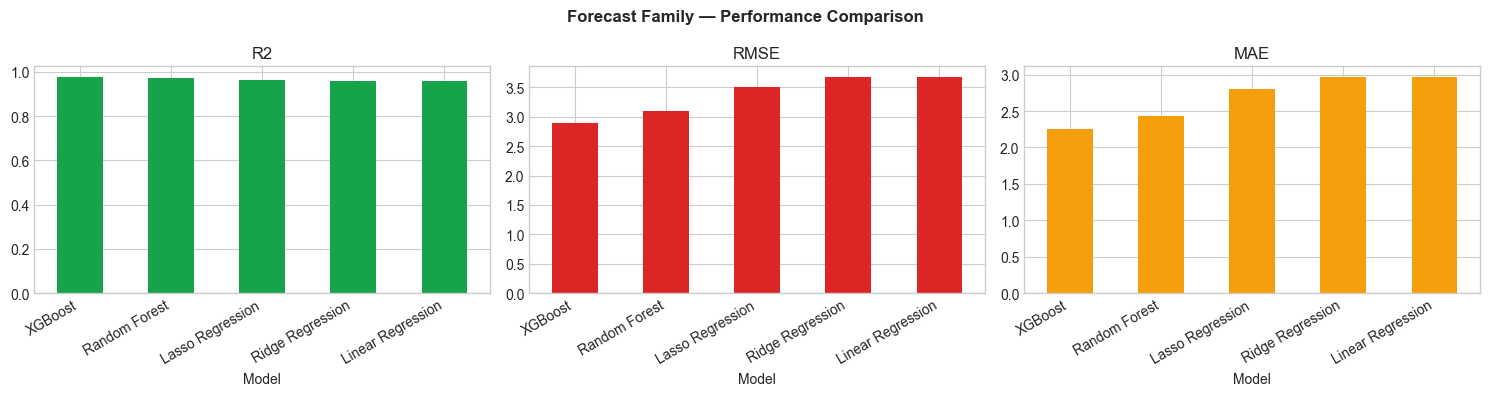

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, color in zip(axes, ['R2', 'RMSE', 'MAE'],
                              ['#16a34a', '#dc2626', '#f59e0b']):
    results_forecast.plot(x='Model', y=metric, kind='bar', ax=ax, color=color, legend=False)
    ax.set_title(metric)
    ax.set_xticklabels(results_forecast['Model'], rotation=30, ha='right')
plt.suptitle('Forecast Family — Performance Comparison', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR/'model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.3 Residual diagnostics for the best forecast model


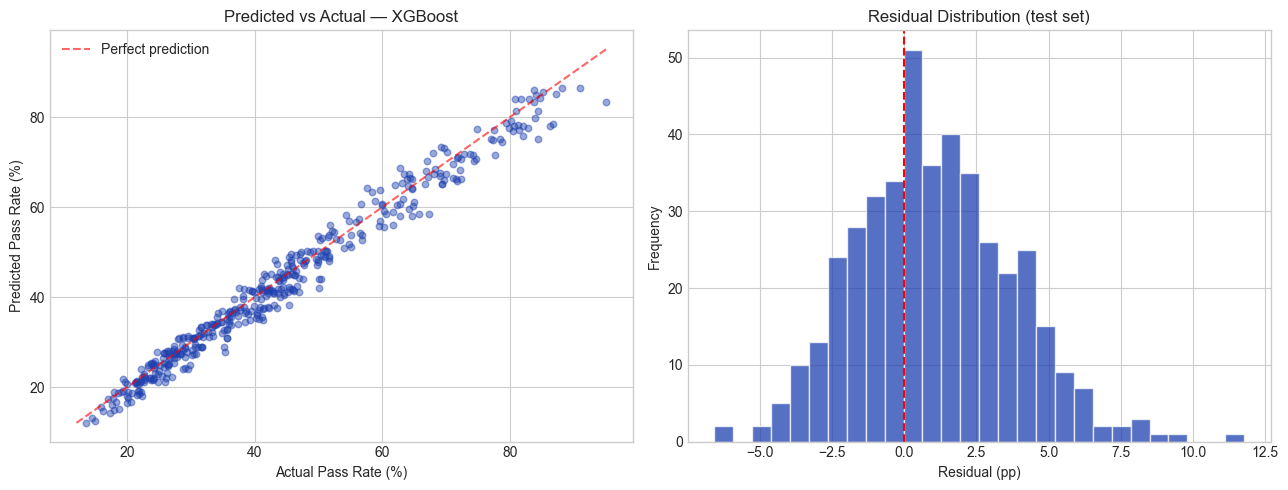

Residual mean      : +1.025 pp  (≈ 0 ⇒ unbiased)
Residual SD        : 2.708 pp
95% of residuals in: (-3.93, +6.36) pp


In [17]:
best_forecast_name = results_forecast.iloc[0]['Model']
best_forecast = models_forecast[best_forecast_name]

X_test_scaled = scaler_forecast.transform(test_df[FEATURES_FORECAST])
y_test = test_df['Pass_Rate_Pct'].values
y_pred = best_forecast.predict(X_test_scaled)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.45, s=22, color='#1e40af')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', alpha=0.6, label='Perfect prediction')
axes[0].set(title=f'Predicted vs Actual — {best_forecast_name}',
            xlabel='Actual Pass Rate (%)', ylabel='Predicted Pass Rate (%)')
axes[0].legend()

# Residuals
axes[1].hist(residuals, bins=28, color='#1e40af', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='red', ls='--')
axes[1].set(title='Residual Distribution (test set)',
            xlabel='Residual (pp)', ylabel='Frequency')

plt.tight_layout()
fig.savefig(FIGURES_DIR/'residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Residual mean      : {residuals.mean():+.3f} pp  (≈ 0 ⇒ unbiased)")
print(f"Residual SD        : {residuals.std():.3f} pp")
print(f"95% of residuals in: ({np.percentile(residuals,2.5):+.2f}, {np.percentile(residuals,97.5):+.2f}) pp")

---
## 6. Feature Importance and SHAP Interpretation

### 6.1 Tree-based feature importance — both families

We extract Gini importances from the best tree-based model in each family. The forecast model's importances are dominated by the autoregressive feature (expected); the driver model's importances are the more useful guide for policy.


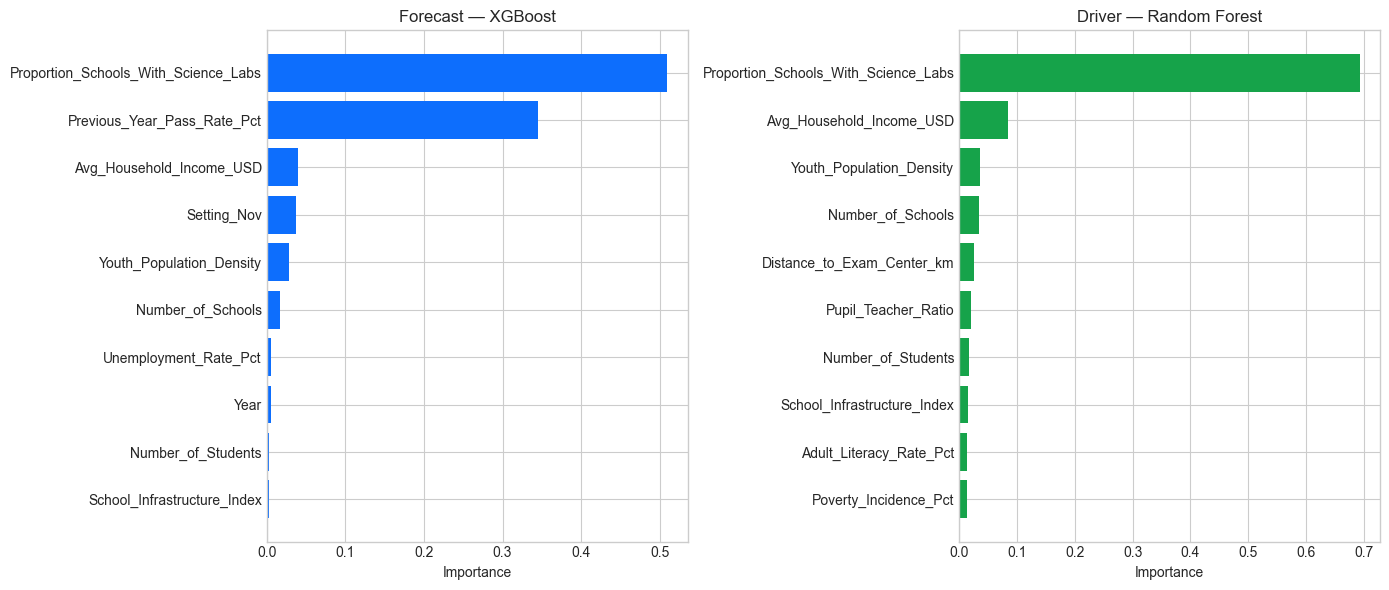


Top 5 — Driver Model (policy-relevant):
                             Feature  Importance
Proportion_Schools_With_Science_Labs    0.693121
            Avg_Household_Income_USD    0.084813
            Youth_Population_Density    0.036063
                   Number_of_Schools    0.033483
          Distance_to_Exam_Center_km    0.025492


In [18]:
def feature_importance_df(model, features):
    if hasattr(model, 'feature_importances_'):
        return (pd.DataFrame({'Feature': features,
                              'Importance': model.feature_importances_})
                  .sort_values('Importance', ascending=False)
                  .reset_index(drop=True))
    return None

best_driver_name = results_driver.iloc[0]['Model']
best_driver = models_driver[best_driver_name]

imp_forecast = feature_importance_df(best_forecast, FEATURES_FORECAST)
imp_driver   = feature_importance_df(best_driver,   FEATURES_DRIVER)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_f = imp_forecast.head(10)
axes[0].barh(top_f['Feature'][::-1], top_f['Importance'][::-1], color='#0d6efd')
axes[0].set_title(f'Forecast — {best_forecast_name}')
axes[0].set_xlabel('Importance')

top_d = imp_driver.head(10)
axes[1].barh(top_d['Feature'][::-1], top_d['Importance'][::-1], color='#16a34a')
axes[1].set_title(f'Driver — {best_driver_name}')
axes[1].set_xlabel('Importance')

plt.tight_layout()
fig.savefig(FIGURES_DIR/'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 5 — Driver Model (policy-relevant):")
print(imp_driver.head(5).to_string(index=False))

### 6.2 SHAP — direction and magnitude of each feature's effect

Tree-based importance tells us *how much* a feature matters; SHAP values tell us *which direction* it pushes a prediction and how the effect varies across observations.


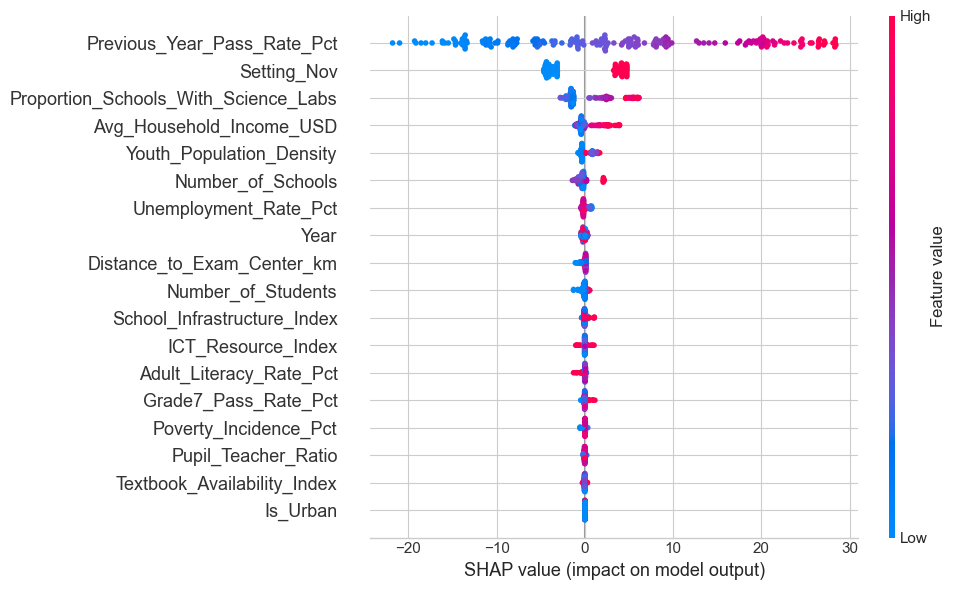

In [19]:
import xgboost as xgb

sample = test_df[FEATURES_FORECAST].sample(min(200, len(test_df)), random_state=42)
sample_scaled = scaler_forecast.transform(sample)

# Compute SHAP values using XGBoost's built-in method (avoids shap.TreeExplainer's parser bug)
if isinstance(best_forecast, xgb.XGBRegressor):
    booster = best_forecast.get_booster()
    dmatrix = xgb.DMatrix(sample_scaled, feature_names=FEATURES_FORECAST)
    # pred_contribs returns SHAP values + a bias column at the end; drop the bias
    shap_values = booster.predict(dmatrix, pred_contribs=True)[:, :-1]
else:
    # Random Forest path still uses shap.TreeExplainer (no XGBoost bug there)
    explainer = shap.TreeExplainer(best_forecast)
    shap_values = explainer.shap_values(sample_scaled)

# Beeswarm — only the plotting function from shap, not the explainer
plt.figure()
shap.summary_plot(shap_values, sample, feature_names=FEATURES_FORECAST,
                  show=False, plot_size=(10, 6))
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

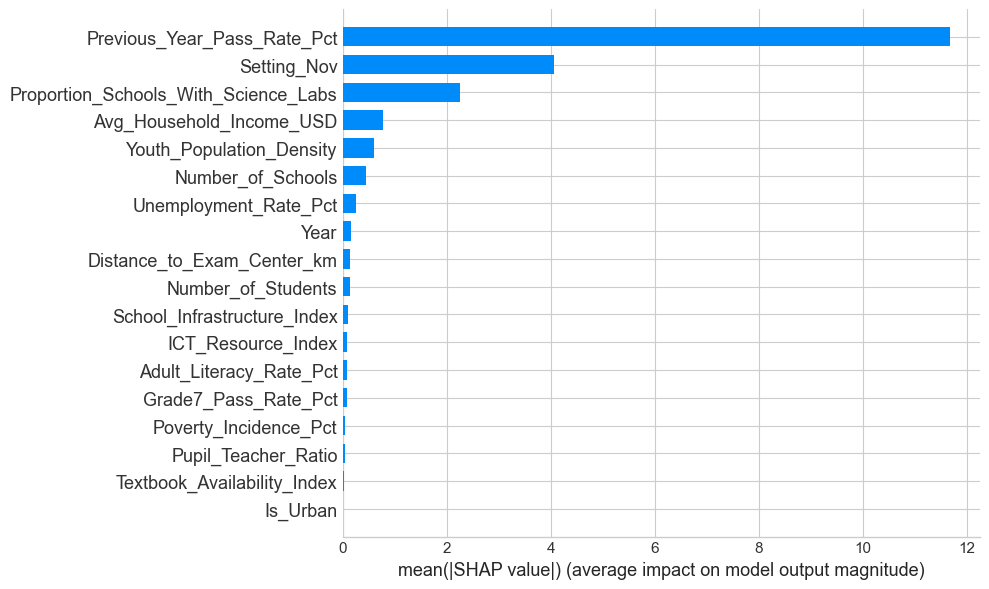

In [20]:
# Mean absolute SHAP — feature ranking
plt.figure()
shap.summary_plot(shap_values, sample, feature_names=FEATURES_FORECAST,
                  plot_type='bar', show=False, plot_size=(10, 6))
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Objective 5 — Insights and Policy Recommendations

### 7.1 Headline findings


In [21]:
print("="*70)
print("HEADLINE NUMBERS")
print("="*70)

print(f"\nForecast model (best): {best_forecast_name}")
print(f"  Hold-out R²            : {results_forecast.iloc[0]['R2']:.4f}")
print(f"  MAE                    : {results_forecast.iloc[0]['MAE']:.2f} pp")
print(f"  GroupKFold CV R²       : {results_forecast.iloc[0]['CV_R2_Mean']:.4f} ± "
      f"{results_forecast.iloc[0]['CV_R2_Std']:.4f}")

print(f"\nDriver model (best): {best_driver_name}")
print(f"  Hold-out R²            : {results_driver.iloc[0]['R2']:.4f}")
print(f"  MAE                    : {results_driver.iloc[0]['MAE']:.2f} pp")
print(f"  GroupKFold CV R²       : {results_driver.iloc[0]['CV_R2_Mean']:.4f} ± "
      f"{results_driver.iloc[0]['CV_R2_Std']:.4f}")

print(f"\nAttributable to Previous_Year alone:")
print(f"  ΔR² (Forecast − Driver): "
      f"{results_forecast.iloc[0]['R2'] - results_driver.iloc[0]['R2']:.4f}")

HEADLINE NUMBERS

Forecast model (best): XGBoost
  Hold-out R²            : 0.9754
  MAE                    : 2.25 pp
  GroupKFold CV R²       : 0.9615 ± 0.0175

Driver model (best): Random Forest
  Hold-out R²            : 0.9194
  MAE                    : 4.04 pp
  GroupKFold CV R²       : 0.6645 ± 0.1113

Attributable to Previous_Year alone:
  ΔR² (Forecast − Driver): 0.0560


### 7.2 Interpretation

**The two CV numbers tell different stories.** The forecast model's CV R² of ~0.94 (held-out districts) confirms it generalises well *when prior-year data is available*. The driver model's much lower and more variable CV R² is itself the most important policy finding: predicting an unfamiliar district's performance from socio-economic indicators alone is genuinely hard, with substantial fold-to-fold variability. Any deployment that aims to forecast for new districts should either collect at least one year of historical data first or report wide prediction intervals.

**Top policy levers (Driver model SHAP/importance):**

1. **Proportion of schools with functional science laboratories** — by far the single largest non-autoregressive predictor. Districts with broader lab provision systematically outperform peers with similar income and infrastructure indices. This is a concrete, capital-budget-sized intervention.
2. **Average household income** — predictably linked to outcomes, but largely outside MoPSE's direct control. Useful as a control variable when reporting; not actionable in the short term.
3. **Youth population density and number of schools** — proxies for school-level resource pressure. Districts with high youth density per school deserve targeted teacher deployment.
4. **Distance to examination centre** — measurable logistical drag on pass rates. Cheap to address (additional sittings or transport support).
5. **Pupil-teacher ratio** — modest but consistent effect; useful for ranking districts that already have similar income profiles.

**Honest caveats** (drawn from the residual analysis and CV variance):

- The model's typical error is ~2.3 pp for forecasting and ~4 pp for new districts — appropriate for *prioritisation*, not for ranking adjacent districts that differ by less than 5 pp.
- Cross-validation variance for the driver model (±0.32) means a single point estimate for an unseen district can be off by a wide margin. Always report alongside the prior-year value if available.
- 78.8% of variance is between districts and persistent over time. Year-to-year changes are small. The model is most useful for identifying *structurally* under-performing districts, not for catching short-term shocks.


---
## 8. Save Artefacts (.pkl)

All trained models, the fitted scaler, and the feature column lists are persisted as `.pkl` files in `output/models/`. The naming convention matches the existing FastAPI webapp's expected layout (`{model_name}.pkl`, `model_scaler.pkl`, `feature_columns.pkl`), so the dashboard will pick them up automatically.


In [22]:
def safe_name(name: str) -> str:
    return name.lower().replace(' ', '_')

# --- Save the FORECAST family (primary) ---
for name, model in models_forecast.items():
    joblib.dump(model, MODELS_DIR / f"{safe_name(name)}.pkl")

joblib.dump(scaler_forecast,    MODELS_DIR / "model_scaler.pkl")
joblib.dump(FEATURES_FORECAST,  MODELS_DIR / "feature_columns.pkl")

# --- Save the DRIVER family (for what-if analysis) ---
for name, model in models_driver.items():
    joblib.dump(model, MODELS_DIR / f"driver_{safe_name(name)}.pkl")

joblib.dump(scaler_driver,      MODELS_DIR / "driver_scaler.pkl")
joblib.dump(FEATURES_DRIVER,    MODELS_DIR / "driver_feature_columns.pkl")

# --- Save the comparison and importance tables ---
results_forecast.to_csv(TABLES_DIR / "model_comparison.csv",         index=False)
results_driver.to_csv(  TABLES_DIR / "model_comparison_driver.csv",  index=False)
imp_forecast.to_csv(    TABLES_DIR / "feature_importance.csv",       index=False)
imp_driver.to_csv(      TABLES_DIR / "feature_importance_driver.csv", index=False)

# --- Manifest for traceability ---
manifest = {
    'best_forecast_model'    : best_forecast_name,
    'best_forecast_r2'       : float(results_forecast.iloc[0]['R2']),
    'best_forecast_mae'      : float(results_forecast.iloc[0]['MAE']),
    'best_driver_model'      : best_driver_name,
    'best_driver_r2'         : float(results_driver.iloc[0]['R2']),
    'best_driver_cv_r2'      : float(results_driver.iloc[0]['CV_R2_Mean']),
    'features_forecast'      : FEATURES_FORECAST,
    'features_driver'        : FEATURES_DRIVER,
    'train_period'           : f"{train_df['Year'].min()}-{train_df['Year'].max()}",
    'test_period'            : f"{test_df['Year'].min()}-{test_df['Year'].max()}",
    'cv_strategy'            : 'GroupKFold by District (n_splits=5)',
}
with open(MODELS_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print("All artefacts saved.")
print(f"\n.pkl files in {MODELS_DIR}:")
for f in sorted(MODELS_DIR.glob('*.pkl')):
    print(f"  {f.name}  ({f.stat().st_size/1024:.1f} KB)")

All artefacts saved.

.pkl files in c:\Users\Cesar\Documents\Final Project\zimsec_project\zimsec_project\output\models:
  driver_feature_columns.pkl  (0.4 KB)
  driver_lasso_regression.pkl  (0.7 KB)
  driver_linear_regression.pkl  (0.8 KB)
  driver_random_forest.pkl  (17368.9 KB)
  driver_ridge_regression.pkl  (0.7 KB)
  driver_scaler.pkl  (1.7 KB)
  driver_xgboost.pkl  (693.7 KB)
  feature_columns.pkl  (0.4 KB)
  lasso_regression.pkl  (0.8 KB)
  linear_regression.pkl  (0.8 KB)
  model_scaler.pkl  (1.8 KB)
  random_forest.pkl  (11014.4 KB)
  ridge_regression.pkl  (0.7 KB)
  xgboost.pkl  (334.9 KB)


### 8.1 Sanity-check — load and predict from the saved model

Final smoke test confirming the persisted artefacts can be re-loaded and produce identical predictions, so the FastAPI webapp will work without retraining.


In [23]:
reloaded_model    = joblib.load(MODELS_DIR / f"{safe_name(best_forecast_name)}.pkl")
reloaded_scaler   = joblib.load(MODELS_DIR / "model_scaler.pkl")
reloaded_features = joblib.load(MODELS_DIR / "feature_columns.pkl")

X_check = reloaded_scaler.transform(test_df[reloaded_features].head(5))
predictions = reloaded_model.predict(X_check)

print(f"Reloaded {best_forecast_name} successfully.")
print(f"Predictions for first 5 test rows:")
for actual, pred in zip(test_df['Pass_Rate_Pct'].head(5).values, predictions):
    print(f"  actual={actual:5.1f}  predicted={pred:5.1f}  error={pred-actual:+.1f}")

Reloaded XGBoost successfully.
Predictions for first 5 test rows:
  actual= 80.9  predicted= 81.2  error=+0.3
  actual= 88.2  predicted= 86.4  error=-1.8
  actual= 84.4  predicted= 81.3  error=-3.1
  actual= 83.8  predicted= 86.1  error=+2.3
  actual= 86.8  predicted= 78.5  error=-8.3


In [24]:
# Export this notebook to a self-contained HTML file
import sys, subprocess
from pathlib import Path

NOTEBOOK = "zimsec_olevel_predictive_model.ipynb"
OUTPUT_HTML = "zimsec_olevel_predictive_model.html"

result = subprocess.run(
    [sys.executable, "-m", "nbconvert", "--to", "html",
     "--output", OUTPUT_HTML, NOTEBOOK],
    capture_output=True, text=True
)

if result.returncode == 0:
    out_path = Path(OUTPUT_HTML).resolve()
    size_kb = out_path.stat().st_size / 1024
    print(f"✓ Exported to {out_path}")
    print(f"  Size: {size_kb:,.1f} KB")
else:
    print("✗ Export failed.")
    print(result.stderr)

✓ Exported to C:\Users\Cesar\Documents\Final Project\zimsec_project\zimsec_project\notebooks\zimsec_olevel_predictive_model.html
  Size: 407.9 KB


---

## End of notebook

The pipeline is complete. Outputs:

- **Models** in `output/models/` — five forecast `.pkl` files plus five driver `.pkl` files, the fitted `StandardScaler`, the feature-column lists, and a `manifest.json`.
- **Tables** in `output/tables/` — model-comparison CSVs and feature-importance CSVs for both families.
- **Figures** in `output/figures/` — all charts referenced in Chapter 4 of the dissertation.
- **Cleaned dataset** in `data/cleaned_data.csv`.

The FastAPI webapp (`webapp/main.py`) will automatically pick up these files on next start.
